# STL Export Demo: From Visualization to 3D Print

This notebook demonstrates how to export complex function visualizations as STL files for 3D printing.

We'll:
1. Visualize a complex function on the Riemann sphere
2. Export it as an STL file suitable for 3D printing
3. Explain the key settings and options

In [1]:
import complexplorer as cp
import numpy as np

# Check if PyVista is available
try:
    import pyvista as pv
    print("✓ PyVista is installed - STL export will work!")
except ImportError:
    print("✗ PyVista not found. Install with: pip install pyvista")

# Render PyVista inline as static images (use examples/scripts/ for interactive views)
pv.set_jupyter_backend('static')

✓ PyVista is installed - STL export will work!


## Step 1: Define and Visualize a Complex Function

Let's start with a beautiful rational function that has interesting features on the Riemann sphere.

In [2]:
# Define our complex function
def f(z):
    """A rational function with poles and zeros."""
    return z / (z**10 - 1)

# Create a colormap for visualization
cmap = cp.Phase(n_phi=12, auto_scale_r=True, v_base=0.4)

print("Function: f(z) = z / (z^10 - 1)")
print("This function has:")
print("- Poles at the 10th roots of unity: e^(2πik/10) for k=0,1,...,9")
print("- Zero at infinity")

Function: f(z) = z / (z^10 - 1)
This function has:
- Poles at the 10th roots of unity: e^(2πik/10) for k=0,1,...,9
- Zero at infinity


C:\Repos\complexplorer\complexplorer\plotting\pyvista\riemann.py:132: UserWarning: PyVista backend is 'static', but 'trame' is recommended for interactive Jupyter visualizations. Set with: pv.set_jupyter_backend('trame')
  ensure_pyvista_setup()


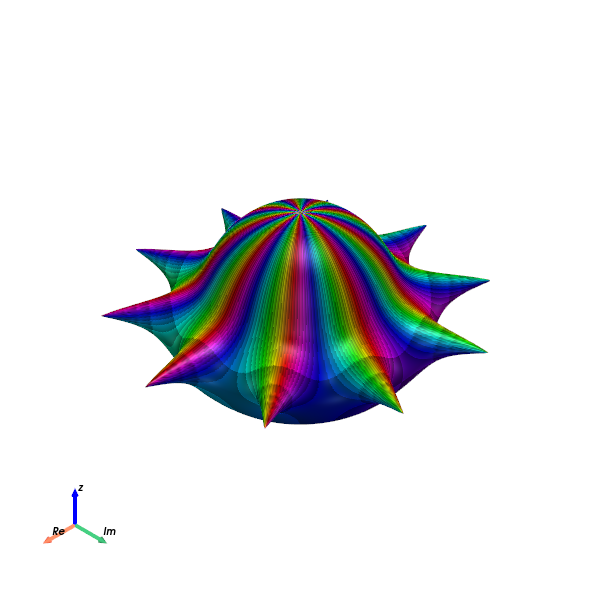

In [3]:
# Visualize on the Riemann sphere
# Note: In Jupyter, we use trame backend which may have aliasing
plotter = cp.riemann_pv(
    f,
    resolution=800,  # Higher resolution for better quality
    cmap=cmap,
    modulus_mode='arctan',  # Smooth compression of modulus
    modulus_params={
        'r_min': 0.5,  # Minimum modulus
        'r_max': 1.0,  # Maximum modulus for better view
    },  # set to True for inline Jupyter display
    window_size=(600, 600),
    return_plotter=True
)

## Step 2: Export to STL for 3D Printing

Now let's export this beautiful visualization as an STL file that can be 3D printed!

In [4]:
from complexplorer.export.stl import OrnamentGenerator

# Create the ornament generator
ornament = OrnamentGenerator(
    func=f,
    resolution=200,  # Higher resolution for quality STL
    scaling='arctan',  # Modulus scaling method
    cmap=cmap,
    domain=None  # Use full sphere
)

print("Ornament generator created with:")
print(f"- Resolution: {ornament.resolution} (affects mesh density)")
print(f"- Scaling: {ornament.scaling} (how modulus maps to radius)")
print(f"- Colormap: Enhanced phase portrait with {cmap.n_phi} sectors")

Ornament generator created with:
- Resolution: 200 (affects mesh density)
- Scaling: arctan (how modulus maps to radius)
- Colormap: Enhanced phase portrait with 12 sectors


### Understanding the Settings

**Resolution**: Controls the mesh density
- Higher values (200-300) = smoother surface, larger file
- Lower values (100-150) = faster generation, smaller file

**Scaling Methods**:
- `'constant'`: Traditional sphere (radius = 1)
- `'arctan'`: Smooth compression, good for functions with poles
- `'logarithmic'`: Emphasizes zeros and poles
- `'linear_clamp'`: Linear up to a maximum

**Domain**: Restrict which parts of the sphere to include
- `None`: Full sphere
- `cp.Disk(5)`: Only |z| < 5
- `cp.Annulus(0.1, 10)`: Exclude origin (good for poles at z=0)

In [5]:
# Generate the STL file
stl_file = ornament.generate_and_save(
    filename='complex_ornament.stl',
    size_mm=80,  # Physical size in millimeters
    repair=True,  # Apply mesh repair for better print quality
    verbose=True  # Show progress
)

print(f"\n✓ STL file created: {stl_file}")
print(f"\nYou can now import this file into your 3D printing software!")

Generating Riemann sphere ornament:
  Resolution: 200
  Scaling: arctan
  Parameters: {'r_min': 0.5, 'r_max': 1.0}
  Generated mesh: 40000 vertices, 39601 faces
  Radius range: [0.500, 0.976]

Repairing mesh...
=== Simple Mesh Repair ===
Input: 40000 points, 39601 faces
Cleaning mesh...
  After clean: 39800 points, 39601 faces
Filling holes...
Initial boundary edges: 560
After filling: 560 boundary edges
Final: 39800 points, 39995 faces
✗ Mesh still has 560 boundary points
=== Mesh Validation Results ===
Watertight: False (551 boundary edges)
Manifold: False (551 non-manifold edges)
Dimensions: 80.000 x 76.880 x 42.597
Volume: 68173.133
Surface area: 9496.741

At 80mm size:
Estimated min wall thickness: 0.30mm
✗ Too thin! Recommend at least 213.3mm

=== Overall Assessment ===
✗ Mesh needs significant repair before printing



Saved STL file: complex_ornament.stl


File size: 3.80 MB

✓ STL file created: complex_ornament.stl

You can now import this file into your 3D printing software!


## Step 3: Customize for Different Functions

Let's try another function with different characteristics:

In [6]:
# A rational function with poles and zeros
def g(z):
    return (z**5 + 1) / (z**3 - 1)

# For functions with rapid growth, restrict the domain
restricted_domain = cp.Disk(3)  # Only consider |z| < 3

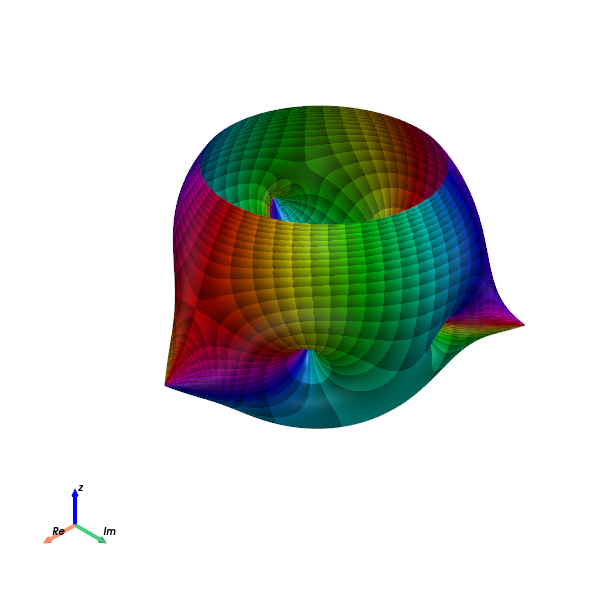

In [7]:
# Visualize on the Riemann sphere
# Note: In Jupyter, we use trame backend which may have aliasing
plotter = cp.riemann_pv(
    g,
    resolution=800,  # Higher resolution for better quality
    cmap=cmap,
    modulus_mode='logarithmic',  # Smooth compression of modulus,  # set to True for inline Jupyter display
    window_size=(600, 600),
    return_plotter=True,
    domain=restricted_domain  # Restrict to disk of radius 3
)

In [8]:
# Create ornament with domain restriction
ornament2 = OrnamentGenerator(
    func=g,
    resolution=150,
    scaling='logarithmic',  # Good for exponential growth
    cmap=cp.Phase(n_phi=8, auto_scale_r=True),
    domain=restricted_domain
)

# Generate STL
stl_file2 = ornament2.generate_and_save(
    filename='exponential_ornament.stl',
    size_mm=70,
    repair=True,
    verbose=True
)

print(f"✓ Created: {stl_file2}")
print("\nDomain restriction helps with:")
print("- Numerical stability")
print("- Avoiding infinite values")
print("- Creating cleaner 3D prints")

Generating Riemann sphere ornament:
  Resolution: 150
  Scaling: logarithmic
  Parameters: {'base': 2.718281828459045, 'r_min': 0.5, 'r_max': 1.0}


  Generated mesh: 17850 vertices, 17582 faces
  Radius range: [0.517, 0.992]

Repairing mesh...
=== Simple Mesh Repair ===
Input: 17850 points, 17582 faces
Cleaning mesh...
  After clean: 17731 points, 17582 faces
Filling holes...
Initial boundary edges: 402
After filling: 402 boundary edges
Final: 17731 points, 17876 faces
✗ Mesh still has 402 boundary points
=== Mesh Validation Results ===
Watertight: False (397 boundary edges)
Manifold: False (397 non-manifold edges)
Dimensions: 70.000 x 67.751 x 60.573
Volume: 106096.579
Surface area: 14143.904

At 70mm size:
Estimated min wall thickness: 0.30mm
✗ Too thin! Recommend at least 186.7mm

=== Overall Assessment ===
✗ Mesh needs significant repair before printing



Saved STL file: exponential_ornament.stl
File size: 1.69 MB
✓ Created: exponential_ornament.stl

Domain restriction helps with:
- Numerical stability
- Avoiding infinite values
- Creating cleaner 3D prints


## Tips for 3D Printing

1. **File Size**: STL files can be large. Resolution 150-200 is usually sufficient.

2. **Printing Settings**:
   - The base is automatically flattened for easy printing
   - No supports needed for most ornaments
   - Use 0.2mm layer height for good detail

3. **Material Choice**:
   - PLA works well for display pieces
   - PETG for outdoor ornaments
   - Resin printing for maximum detail

4. **Scaling in Slicer**:
   - The `size_mm` parameter sets the diameter
   - You can rescale in your slicer software

5. **Color**: 
   - STL files don't include color information
   - Consider painting or using multi-color printing techniques

## Advanced: Custom Scaling Function

For complete control over the 3D shape, you can define custom scaling:

In [9]:
# Define a custom scaling function
def custom_scale(moduli):
    """Custom scaling that emphasizes mid-range values."""
    # Sigmoid-like scaling
    return 1 / (1 + np.exp(-2 * (moduli - 1)))

# Create ornament with custom scaling
ornament3 = OrnamentGenerator(
    func=lambda z: z**4 - 1,  # Simple polynomial
    resolution=180,
    scaling='custom',
    scaling_params={'scaling_func': custom_scale},
    cmap=cp.Phase(n_phi=16, auto_scale_r=True)
)

# Generate
stl_file3 = ornament3.generate_and_save(
    filename='custom_scaling_ornament.stl',
    size_mm=75,
    verbose=True
)

print(f"✓ Created with custom scaling: {stl_file3}")

Generating Riemann sphere ornament:
  Resolution: 180
  Scaling: custom
  Parameters: {'scaling_func': <function custom_scale at 0x0000029C5D4BF7E0>}
  Generated mesh: 32400 vertices, 32041 faces
  Radius range: [0.127, 1.000]

Repairing mesh...
=== Simple Mesh Repair ===
Input: 32400 points, 32041 faces
Cleaning mesh...
  After clean: 32220 points, 32041 faces
Filling holes...
Initial boundary edges: 425
After filling: 425 boundary edges
Final: 32220 points, 32395 faces
✗ Mesh still has 425 boundary points
=== Mesh Validation Results ===
Watertight: False (422 boundary edges)
Manifold: False (422 non-manifold edges)
Dimensions: 74.998 x 75.000 x 60.634
Volume: 143814.832
Surface area: 15263.367

At 75mm size:
Estimated min wall thickness: 0.30mm
✗ Too thin! Recommend at least 200.0mm

=== Overall Assessment ===
✗ Mesh needs significant repair before printing



Saved STL file: custom_scaling_ornament.stl
File size: 3.07 MB
✓ Created with custom scaling: custom_scaling_ornament.stl


## Summary

You've learned how to:
1. Visualize complex functions on the Riemann sphere
2. Export them as STL files for 3D printing
3. Control the appearance with scaling methods
4. Handle difficult functions with domain restrictions
5. Create custom scaling for artistic effects

Now you can turn any complex function into a physical object!